<a href="https://colab.research.google.com/github/smagadi/AIML/blob/master/GenAI/Stocks/StockPredictionML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install yfinance pandas ta scikit-learn matplotlib seaborn


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=cee98024f30ca61b88dbfacfedca6748b6283d9142a1ebf95fac02455478dd2e
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [3]:
# MODIFIED CODE -------



import matplotlib.pyplot as plt  # Required by some ta or yfinance functionalities
import yfinance as yf
import ta
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
import warnings

# Filter out the specific FutureWarning related to casting single-element Series to float
warnings.filterwarnings("ignore", message="Calling float on a single element Series is deprecated", category=FutureWarning)

warnings.filterwarnings("ignore", message="X has feature names, but RandomForestRegressor was fitted without feature names", category=UserWarning)




In [4]:
# Step 1: Get historical stock data
def get_stock_data(ticker, period='2y', interval='1d'):
    df = yf.download(ticker, period=period, interval=interval)
    df.dropna(inplace=True)
    return df

# Step 2: Add technical indicators
def add_technical_indicators(df):
    # Ensure 'Close' is treated as a Series
    close_prices = df['Close'].squeeze()

    # Calculate indicators
    df['EMA'] = ta.trend.ema_indicator(close=close_prices, window=20).fillna(0) # Consider dropping NaNs instead of filling with 0
    df['RSI'] = ta.momentum.rsi(close=close_prices, window=14).fillna(0) # Consider dropping NaNs instead of filling with 0

    macd = ta.trend.MACD(close=close_prices)
    df['MACD'] = macd.macd()
    df['MACD_signal'] = macd.macd_signal()

    bb = ta.volatility.BollingerBands(close=close_prices)
    df['BB_upper'] = bb.bollinger_hband()
    df['BB_lower'] = bb.bollinger_lband()

    # Drop NaNs introduced by the indicators (usually at the beginning)
    df.dropna(inplace=True)

    return df

# Load data
df = get_stock_data('INFY.NS')
print("Columns after initial data load:", df.columns)

df = add_technical_indicators(df)
# The dropna after adding indicators is now inside the function

# Step 3: Prepare features and target
features = ['EMA', 'RSI', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'Volume']
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

X = df[features].copy()
y = df['Target'].copy()

# Step 4: Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# Random Forest
mae_scores_rf = []
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
    model_rf.fit(X_train, y_train)
    y_pred = model_rf.predict(X_test)
    mae_scores_rf.append(mean_absolute_error(y_test, y_pred))

print(f"Average MAE (Random Forest): {np.mean(mae_scores_rf):.4f}")

# XGBoost
mae_scores_xgb = []
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    # XGBoost can work with pandas DataFrames/Series, but using .values is also common
    model_xgb.fit(X_train, y_train)
    y_pred = model_xgb.predict(X_test)
    mae_scores_xgb.append(mean_absolute_error(y_test, y_pred))

print(f"Average MAE (XGBoost): {np.mean(mae_scores_xgb):.4f}")

# Step 5: Predict future prices dynamically
# This function also needs to handle potentially 2D input from the rolling_prices_xgb list
def add_tech_indicators_for_series(close_series):
    # Ensure input is a pandas Series
    close_series = pd.Series(close_series).squeeze()

    # Check if there are enough data points for indicators
    if len(close_series.dropna()) < 26: # Use dropna() just in case there are NaNs in the list
         return {key: np.nan for key in ['EMA', 'RSI', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower']}

    # Calculate indicators (ensure they return a single value for the last point)
    ema = ta.trend.ema_indicator(close=close_series, window=20).iloc[-1]
    rsi = ta.momentum.rsi(close=close_series, window=14).iloc[-1]
    macd = ta.trend.MACD(close=close_series)
    bb = ta.volatility.BollingerBands(close=close_series)

    # Return the last calculated value for each indicator
    return {
        'EMA': ema,
        'RSI': rsi,
        'MACD': macd.macd().iloc[-1],
        'MACD_signal': macd.macd_signal().iloc[-1],
        'BB_upper': bb.bollinger_hband().iloc[-1],
        'BB_lower': bb.bollinger_lband().iloc[-1]
    }

# Future predictions using Random Forest
# Ensure model_rf is defined and trained on the full dataset X, y before this loop
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X, y) # Retrain on all data for final prediction

last_features_rf = X.iloc[-1:].copy()
# Start rolling prices with actual historical data points required for indicator calculation window
# Ensure we have enough history, 60 might be sufficient for a 20-day EMA and 14-day RSI
# Correcting to ensure .tolist() is called on a Series
rolling_prices_rf = df['Close'].iloc[-max(20, 14, 26) -10:].squeeze().tolist() # Use .squeeze() to ensure it's a Series before .tolist()


print("\nNext 180 predicted closing prices using RandomForest:")
predictions_rf = []
for i in range(180):
    # Ensure last_features_rf is a DataFrame matching X's columns
    if not isinstance(last_features_rf, pd.DataFrame):
         last_features_rf = pd.DataFrame([last_features_rf], columns=features)

    pred = model_rf.predict(last_features_rf)[0]
    predictions_rf.append(pred)
    rolling_prices_rf.append(pred)
    # Keep only the recent prices needed for indicator calculation
    rolling_prices_rf = rolling_prices_rf[-max(20, 14, 26) - 10:] # Keep the buffer

    recalc = add_tech_indicators_for_series(rolling_prices_rf)

    # Check if any required indicator value is NaN
    if any(pd.isna(recalc.get(key)) for key in features if key != 'Volume'):
         print(f"Day {i+1}: Unable to calculate all required features. Stopping.")
         # If calculation fails, the subsequent prediction will likely be unreliable
         # We might want to break the loop or use a fallback
         break # Stop the loop if indicators cannot be calculated

    # Prepare the next input features DataFrame
    next_input_data = recalc
    # Volume prediction is complex, using the last known volume for simplicity as in original code
    next_input_data['Volume'] = last_features_rf['Volume'].iloc[0] # Keep the last known Volume
    next_input = pd.DataFrame([next_input_data], columns=features)


    last_features_rf = next_input
    print(f"Day {i+1}: ₹{pred:.2f}")


# Future predictions using XGBoost
# Ensure model_xgb is defined and trained on the full dataset X, y before this loop
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_xgb.fit(X, y) # Retrain on all data for final prediction


print("\nNext 180 predicted closing prices using XGBoost:")
predictions_xgb = []
last_features_xgb = X.iloc[-1:].copy()
# Start rolling prices with actual historical data points required for indicator calculation window
# Correcting to ensure .tolist() is called on a Series
rolling_prices_xgb = df['Close'].iloc[-max(20, 14, 26) - 10:].squeeze().tolist() # Use .squeeze() to ensure it's a Series before .tolist()


for i in range(180):
    # Ensure last_features_xgb is a DataFrame matching X's columns, and convert to values for xgb
    if not isinstance(last_features_xgb, pd.DataFrame):
         last_features_xgb = pd.DataFrame([last_features_xgb], columns=features)

    # XGBoost model trained on .values previously, so predict with .values
    pred = model_xgb.predict(last_features_xgb.values)[0]
    predictions_xgb.append(pred)
    rolling_prices_xgb.append(pred)
    # Keep only the recent prices needed for indicator calculation
    rolling_prices_xgb = rolling_prices_xgb[-max(20, 14, 26) - 10:] # Keep the buffer

    recalc = add_tech_indicators_for_series(rolling_prices_xgb)

    # Check if any required indicator value is NaN
    if any(pd.isna(recalc.get(key)) for key in features if key != 'Volume'):
         print(f"Day {i+1}: Unable to calculate all required features. Stopping.")
         break # Stop the loop if indicators cannot be calculated


    # Prepare the next input features DataFrame
    next_input_data = recalc
    # Volume prediction is complex, using the last known volume for simplicity as in original code
    next_input_data['Volume'] = last_features_xgb['Volume'].iloc[0] # Keep the last known Volume
    next_input = pd.DataFrame([next_input_data], columns=features)

    last_features_xgb = next_input
    print(f"Day {i+1}: ₹{pred:.2f}")
# %%

/tmp/ipython-input-4-665501934.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed


Columns after initial data load: MultiIndex([( 'Close', 'INFY.NS'),
            (  'High', 'INFY.NS'),
            (   'Low', 'INFY.NS'),
            (  'Open', 'INFY.NS'),
            ('Volume', 'INFY.NS')],
           names=['Price', 'Ticker'])
Average MAE (Random Forest): 102.4085
Average MAE (XGBoost): 105.6997

Next 180 predicted closing prices using RandomForest:
Day 1: ₹1623.03
Day 2: ₹1622.59
Day 3: ₹1620.28
Day 4: ₹1621.45
Day 5: ₹1620.34
Day 6: ₹1621.57
Day 7: ₹1617.38
Day 8: ₹1591.15
Day 9: ₹1587.42
Day 10: ₹1567.75
Day 11: ₹1552.96
Day 12: ₹1536.65
Day 13: ₹1529.58
Day 14: ₹1523.23
Day 15: ₹1532.40
Day 16: ₹1540.08
Day 17: ₹1523.06
Day 18: ₹1486.03
Day 19: ₹1452.14
Day 20: ₹1429.94
Day 21: ₹1429.20
Day 22: ₹1430.47
Day 23: ₹1428.95
Day 24: ₹1425.78
Day 25: ₹1426.33
Day 26: ₹1425.76
Day 27: ₹1425.50
Day 28: ₹1424.33
Day 29: ₹1425.75
Day 30: ₹1423.03
Day 31: ₹1412.30
Day 32: ₹1395.99
Day 33: ₹1380.73
Day 34: ₹1376.85
Day 35: ₹1381.00
Day 36: ₹1381.88
Day 37: ₹1376.57
Day 38: 

In [5]:
# prompt: # prompt: generate a code that takes a list of  Stocks names and calls the above cell code , store the data datewise , price predicted for a particular model .Store this in Google drive permanent storage

from google.colab import drive
drive.mount('/content/drive')

import os

def predict_and_save(stock_tickers):
    base_save_path = "/content/drive/My Drive/StockPredictions"
    os.makedirs(base_save_path, exist_ok=True)

    for ticker in stock_tickers:
        print(f"\nProcessing {ticker}...")
        try:
            # Call the stock data retrieval and prediction code from the previous cell
            # This assumes the previous cell's code is executed and the functions
            # like get_stock_data, add_technical_indicators, model_rf, model_xgb,
            # and the prediction loops are available in the global scope.

            # Re-run the data loading and model fitting for each ticker
            df = get_stock_data(ticker)
            df = add_technical_indicators(df)

            # Prepare features and target again for the new ticker
            features = ['EMA', 'RSI', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'Volume']
            df['Target'] = df['Close'].shift(-1)
            df.dropna(inplace=True)

            if df.empty:
                print(f"Not enough data for {ticker} after cleaning. Skipping.")
                continue

            X = df[features].copy()
            y = df['Target'].copy()

            # Retrain models on the full dataset for the current ticker
            model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
            model_rf.fit(X, y)

            model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
            model_xgb.fit(X, y)

            # Generate predictions (using the existing prediction loops)
            # We need to capture the predictions and the dates associated with them

            # For Random Forest
            predictions_rf = []
            # Start from the last known date in the historical data
            current_date_rf = df.index[-1]
            dates_rf = [current_date_rf + pd.Timedelta(days=i+1) for i in range(180)] # Assume daily predictions

            last_features_rf = X.iloc[-1:].copy()
            rolling_prices_rf = df['Close'].iloc[-max(20, 14, 26) -10:].squeeze().tolist()


            print(f"\nPredicting next 180 days for {ticker} using RandomForest:")
            for i in range(180):
                if not isinstance(last_features_rf, pd.DataFrame):
                     last_features_rf = pd.DataFrame([last_features_rf], columns=features)

                pred = model_rf.predict(last_features_rf)[0]
                predictions_rf.append(pred)
                rolling_prices_rf.append(pred)
                rolling_prices_rf = rolling_prices_rf[-max(20, 14, 26) - 10:]

                recalc = add_tech_indicators_for_series(rolling_prices_rf)

                if any(pd.isna(recalc.get(key)) for key in features if key != 'Volume'):
                     print(f"Day {i+1}: Unable to calculate all required features for {ticker}. Stopping.")
                     break

                next_input_data = recalc
                next_input_data['Volume'] = last_features_rf['Volume'].iloc[0]
                next_input = pd.DataFrame([next_input_data], columns=features)
                last_features_rf = next_input


            # For XGBoost
            predictions_xgb = []
            # Start from the last known date in the historical data
            current_date_xgb = df.index[-1]
            dates_xgb = [current_date_xgb + pd.Timedelta(days=i+1) for i in range(180)] # Assume daily predictions

            last_features_xgb = X.iloc[-1:].copy()
            rolling_prices_xgb = df['Close'].iloc[-max(20, 14, 26) - 10:].squeeze().tolist()


            print(f"\nPredicting next 180 days for {ticker} using XGBoost:")
            for i in range(180):
                if not isinstance(last_features_xgb, pd.DataFrame):
                     last_features_xgb = pd.DataFrame([last_features_xgb], columns=features)

                pred = model_xgb.predict(last_features_xgb.values)[0]
                predictions_xgb.append(pred)
                rolling_prices_xgb.append(pred)
                rolling_prices_xgb = rolling_prices_xgb[-max(20, 14, 26) - 10:]

                recalc = add_tech_indicators_for_series(rolling_prices_xgb)

                if any(pd.isna(recalc.get(key)) for key in features if key != 'Volume'):
                     print(f"Day {i+1}: Unable to calculate all required features for {ticker}. Stopping.")
                     break

                next_input_data = recalc
                next_input_data['Volume'] = last_features_xgb['Volume'].iloc[0]
                next_input = pd.DataFrame([next_input_data], columns=features)
                last_features_xgb = next_input


            # Store the data date-wise
            data_rf = pd.DataFrame({'Date': dates_rf[:len(predictions_rf)], 'PredictedPrice_RF': predictions_rf})
            data_xgb = pd.DataFrame({'Date': dates_xgb[:len(predictions_xgb)], 'PredictedPrice_XGB': predictions_xgb})

            # Merge the predictions based on date
            combined_predictions = pd.merge(data_rf, data_xgb, on='Date', how='outer')

            # Set Date as index for easier handling if needed
            combined_predictions.set_index('Date', inplace=True)

            # Save to Google Drive
            file_name = f"{ticker}_predictions.csv"
            save_path = os.path.join(base_save_path, file_name)
            combined_predictions.to_csv(save_path)
            print(f"Predictions for {ticker} saved to {save_path}")

        except Exception as e:
            print(f"An error occurred while processing {ticker}: {e}")

# Example usage:
# Define the list of stock tickers you want to process
stock_list = ['INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 'BEL.NS'] # Replace with your desired list

# Call the function to get predictions and save them
predict_and_save(stock_list)



/tmp/ipython-input-4-665501934.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Processing INFY.NS...



Predicting next 180 days for INFY.NS using RandomForest:

Predicting next 180 days for INFY.NS using XGBoost:
Predictions for INFY.NS saved to /content/drive/My Drive/StockPredictions/INFY.NS_predictions.csv

Processing HDFCBANK.NS...


/tmp/ipython-input-4-665501934.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed



Predicting next 180 days for HDFCBANK.NS using RandomForest:

Predicting next 180 days for HDFCBANK.NS using XGBoost:
Predictions for HDFCBANK.NS saved to /content/drive/My Drive/StockPredictions/HDFCBANK.NS_predictions.csv

Processing ICICIBANK.NS...


...


Predicting next 180 days for ICICIBANK.NS using RandomForest:

Predicting next 180 days for ICICIBANK.NS using XGBoost:
Predictions for ICICIBANK.NS saved to /content/drive/My Drive/StockPredictions/ICICIBANK.NS_predictions.csv

Processing BHARTIARTL.NS...


/tmp/ipython-input-4-665501934.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed



Predicting next 180 days for BHARTIARTL.NS using RandomForest:

Predicting next 180 days for BHARTIARTL.NS using XGBoost:
Predictions for BHARTIARTL.NS saved to /content/drive/My Drive/StockPredictions/BHARTIARTL.NS_predictions.csv

Processing BEL.NS...


/tmp/ipython-input-4-665501934.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval)
[*********************100%***********************]  1 of 1 completed



Predicting next 180 days for BEL.NS using RandomForest:

Predicting next 180 days for BEL.NS using XGBoost:
Predictions for BEL.NS saved to /content/drive/My Drive/StockPredictions/BEL.NS_predictions.csv


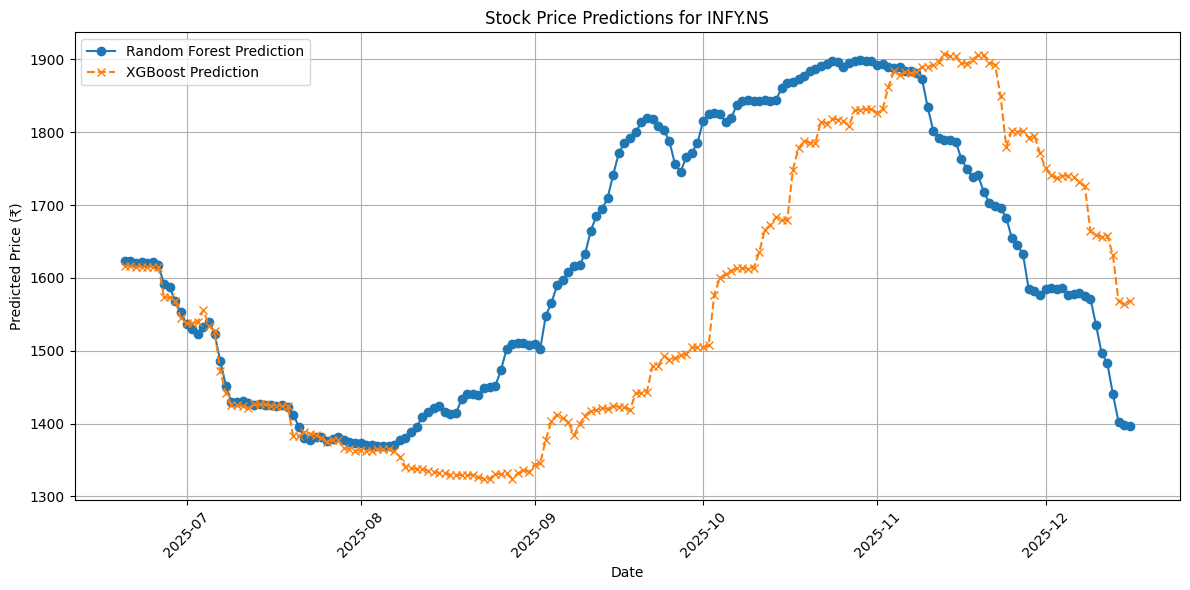

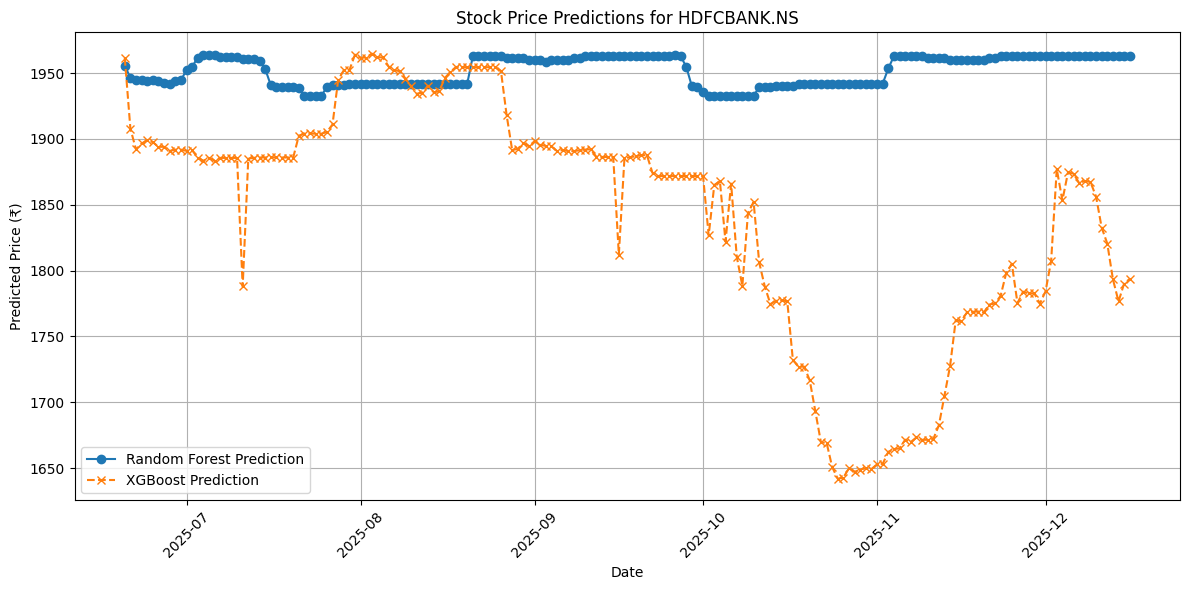

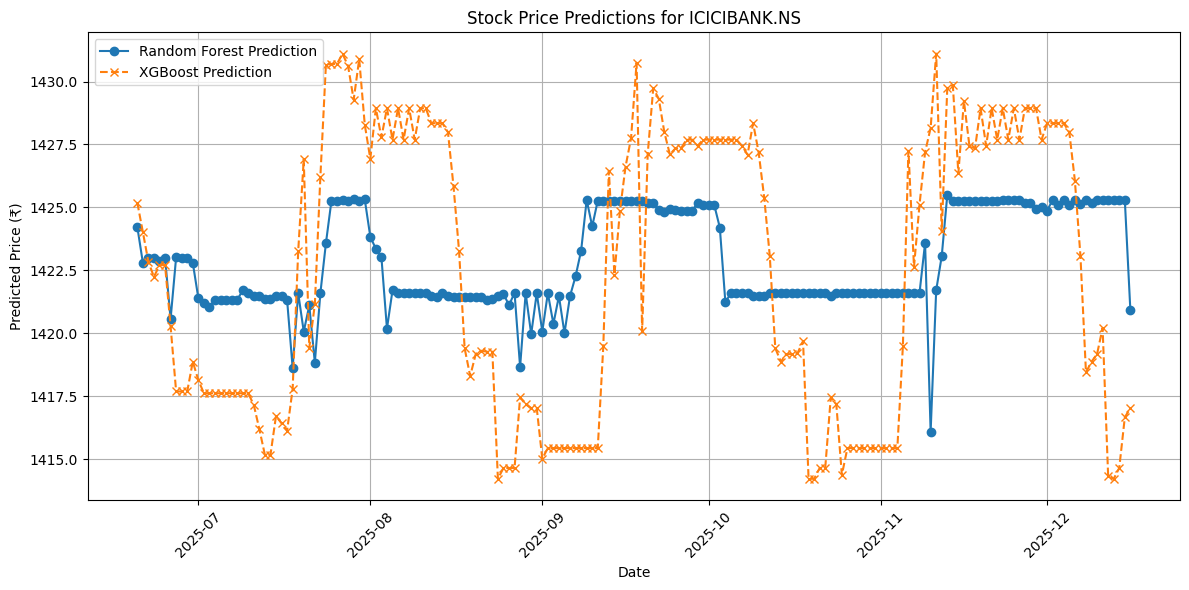

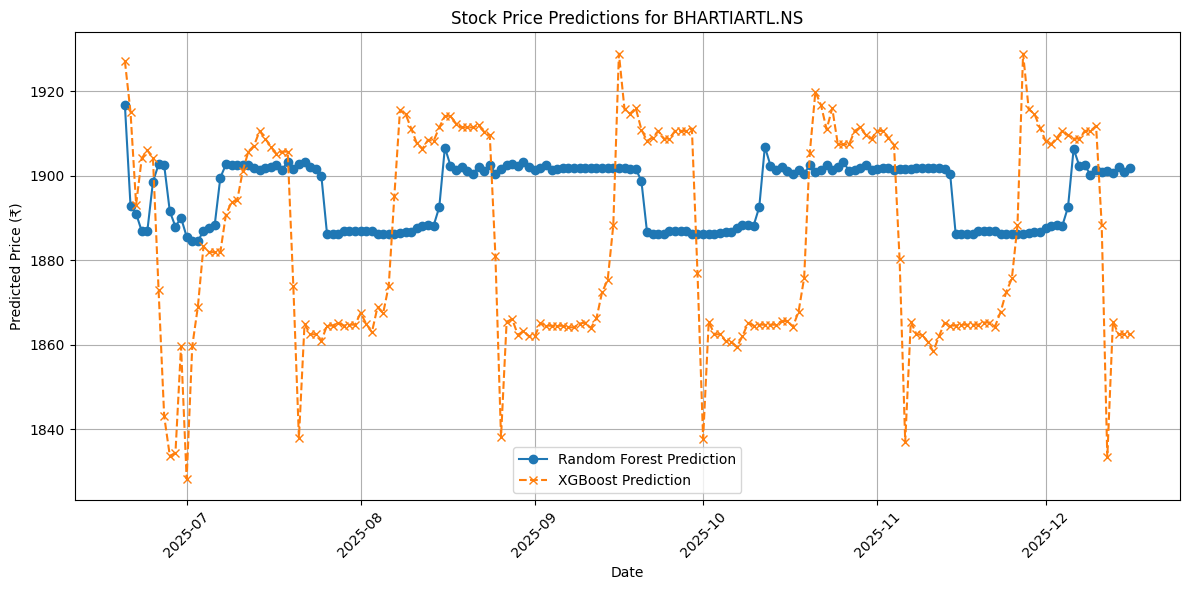

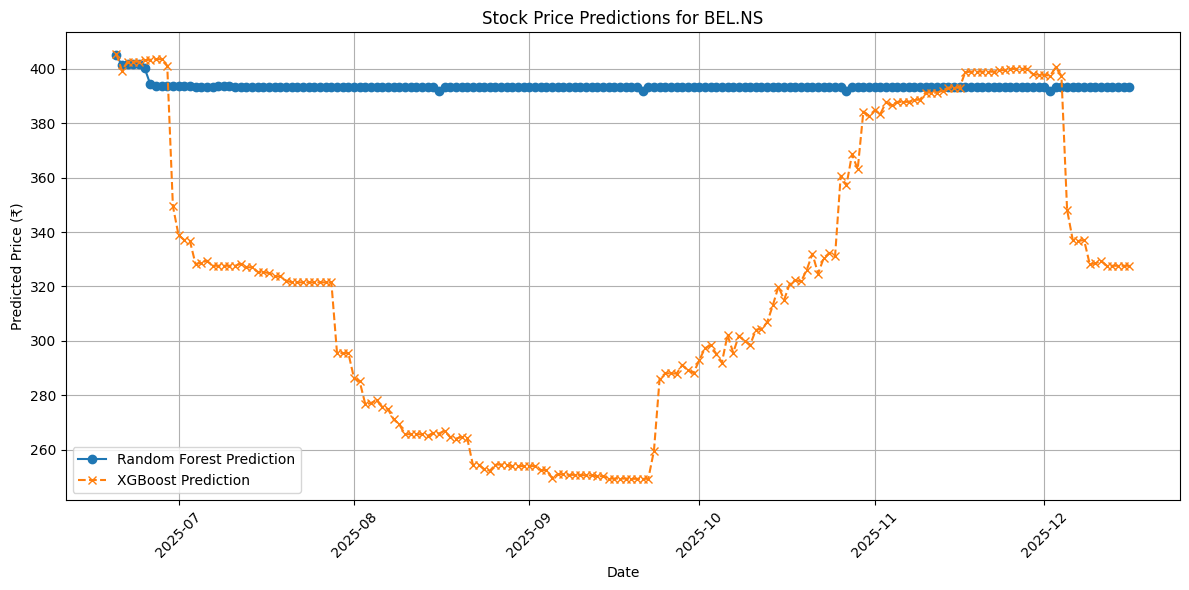

In [7]:
# prompt: Read the prediction data saved in the files and generate a graph

import matplotlib.pyplot as plt
import pandas as pd
import os

def load_and_plot_predictions(stock_tickers, base_load_path="/content/drive/My Drive/StockPredictions"):
    for ticker in stock_tickers:
        file_name = f"{ticker}_predictions.csv"
        load_path = os.path.join(base_load_path, file_name)

        if not os.path.exists(load_path):
            print(f"Prediction file not found for {ticker} at {load_path}. Skipping.")
            continue

        try:
            # Load the predictions
            predictions_df = pd.read_csv(load_path, index_col='Date', parse_dates=True)

            # Plot the data
            plt.figure(figsize=(12, 6))
            plt.plot(predictions_df.index, predictions_df['PredictedPrice_RF'], label='Random Forest Prediction', marker='o', linestyle='-')
            plt.plot(predictions_df.index, predictions_df['PredictedPrice_XGB'], label='XGBoost Prediction', marker='x', linestyle='--')

            plt.title(f'Stock Price Predictions for {ticker}')
            plt.xlabel('Date')
            plt.ylabel('Predicted Price (₹)')
            plt.legend()
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"An error occurred while loading or plotting predictions for {ticker}: {e}")

# Example usage:
# Ensure Google Drive is mounted before calling this function
# drive.mount('/content/drive') # Assuming this is already done in the previous code

# Define the list of stock tickers for which you saved predictions
stock_list_to_plot = ['INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'BHARTIARTL.NS', 'BEL.NS'] # Use the same list you used for saving

# Call the function to load and plot the predictions
load_and_plot_predictions(stock_list_to_plot)
